<a href="https://colab.research.google.com/github/ritesh23r/insurance-cost-prediction/blob/main/Insurance_Cost_Prediction_EDA%2CFeature_Engineering_%26_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [45]:
data = pd.read_csv('insurance.csv')

In [46]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# **EDA**

In [47]:
data.shape

(1338, 7)

In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [49]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [50]:
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [51]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

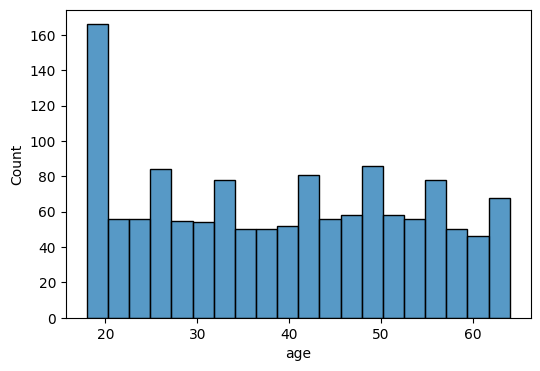

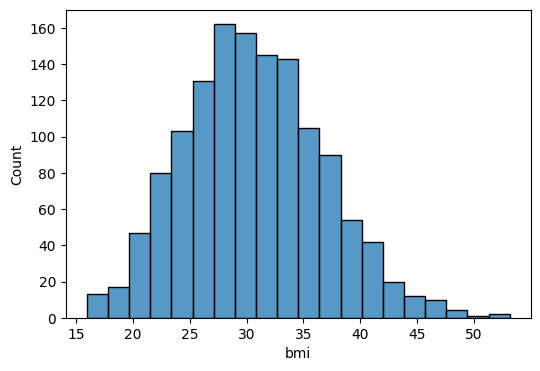

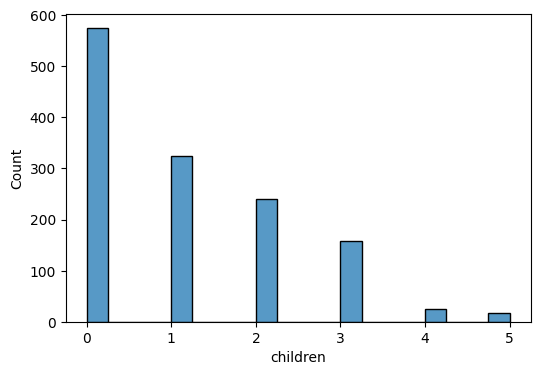

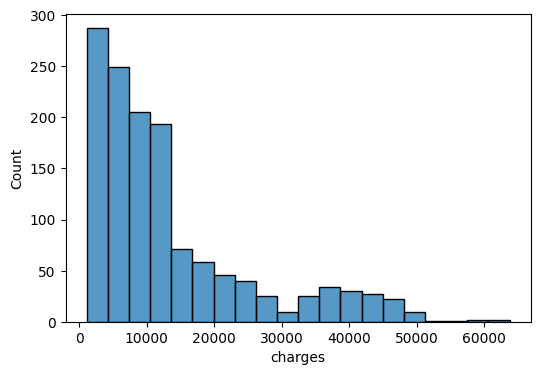

In [52]:
numeric_col = ['age', 'bmi', 'children', 'charges']
for col in numeric_col :
  plt.figure(figsize=(6,4))
  sns.histplot(data[col], kde = False , bins = 20)

<Axes: xlabel='sex', ylabel='count'>

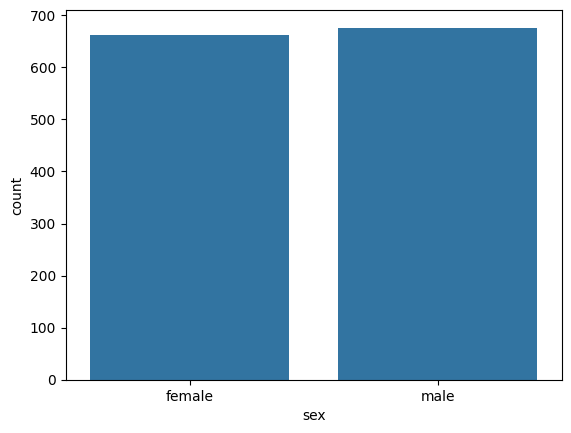

In [53]:
sns.countplot(x=data['sex'])

<Axes: xlabel='smoker', ylabel='count'>

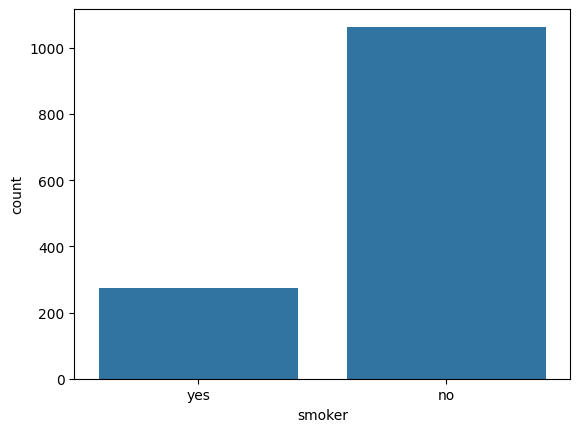

In [54]:
sns.countplot(x=data['smoker'])

<Axes: xlabel='children', ylabel='count'>

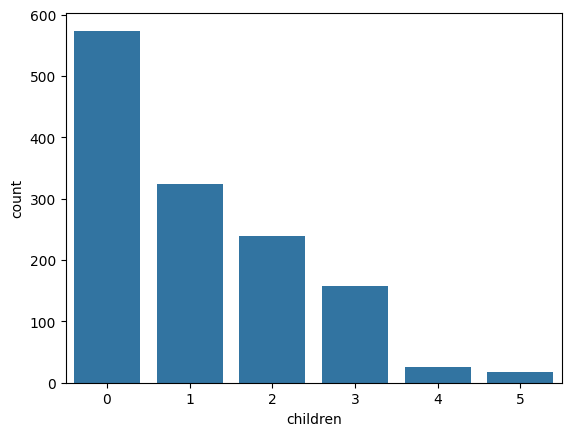

In [55]:
sns.countplot(x=data['children'])

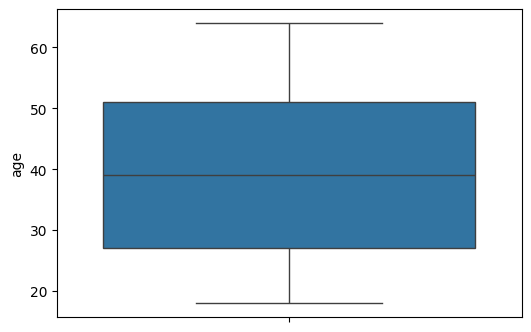

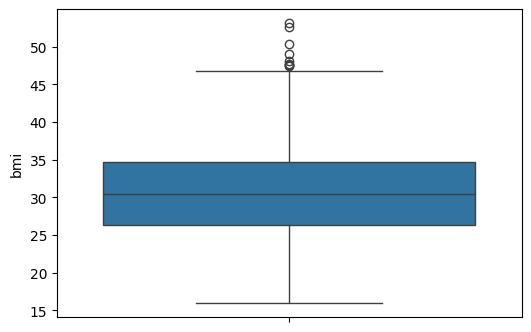

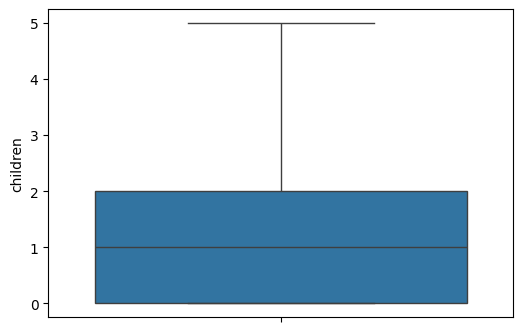

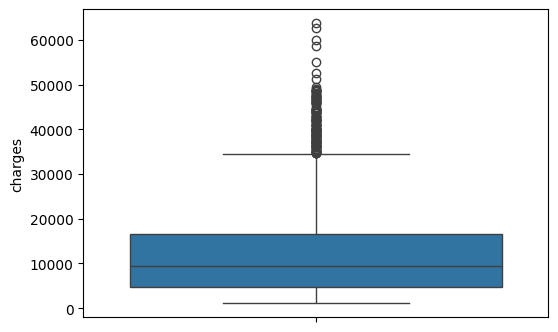

In [56]:
for col in numeric_col :
  plt.figure(figsize=(6,4))
  sns.boxplot(data[col])

<Axes: >

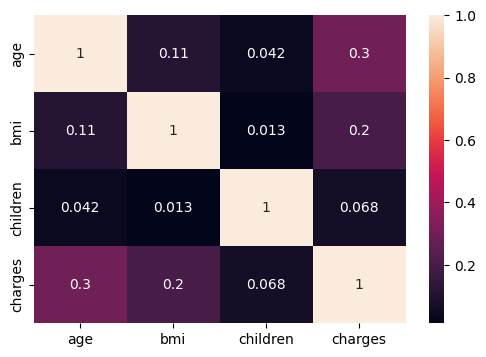

In [57]:
plt.figure(figsize=(6,4))
sns.heatmap(data.corr(numeric_only=True), annot = True)

# **Data Cleaning and Preprocessing**

In [58]:
data_cleaned = data.copy()

In [59]:
data_cleaned.drop_duplicates(inplace = True)

In [60]:
data_cleaned.shape

(1337, 7)

In [61]:
data_cleaned.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [62]:
data_cleaned['sex'].value_counts()

,count
sex,
male,675
female,662


In [63]:
data_cleaned['sex'] = data_cleaned['sex'].map({'male':0, 'female':1})

In [64]:
data_cleaned['smoker'] = data_cleaned['smoker'].map({'yes':1 , 'no' : 0})

In [65]:
data_cleaned.rename(
  columns ={
      'sex' : 'is_female',
      'smoker' : 'is_smoker'
  },inplace = True
)

In [66]:
data_cleaned['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


In [67]:
data_cleaned = pd.get_dummies(data_cleaned, columns=['region'],drop_first=True)

In [68]:
data_cleaned=data_cleaned.astype(int)

# **Feature Engineering and Extraction**

<Axes: xlabel='bmi', ylabel='Count'>

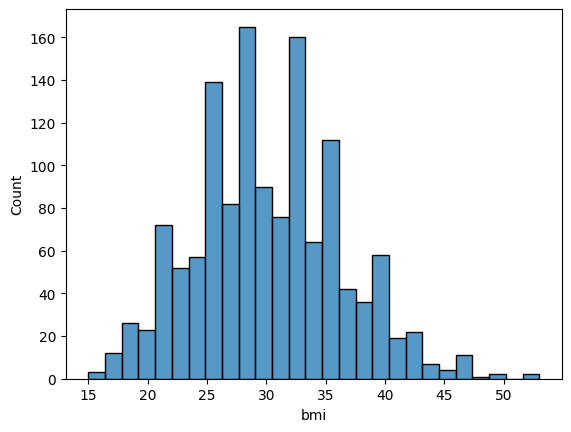

In [69]:
sns.histplot(data_cleaned['bmi'])

In [70]:
data_cleaned['bmi_category'] = pd.cut(
    data_cleaned['bmi'],
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

In [71]:
data_cleaned = pd.get_dummies(data_cleaned,columns=['bmi_category'],drop_first=True)

In [72]:
data_cleaned=data_cleaned.astype(int)

In [73]:
from sklearn.preprocessing import StandardScaler
cols = ['age','bmi','children']
scaler = StandardScaler()
data_cleaned[cols] = scaler.fit_transform(data_cleaned[cols])

In [74]:
data_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [75]:
data_cleaned.corr()['charges'].sort_values(ascending=False)

,charges
charges,1.000000
is_smoker,0.787234
age,0.298309
bmi_category_Obese,0.200348
bmi,0.196236
region_southeast,0.073577
children,0.067390
region_northwest,-0.038695
region_southwest,-0.043637
is_female,-0.058046


In [76]:
cat_features = [
    'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

In [77]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

data_cleaned['charges_bin'] = pd.qcut(data_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    # Corrected df_cleaned to data_cleaned
    contingency = pd.crosstab(data_cleaned[col], data_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
is_smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
is_female,10.258784,0.01649,Reject Null (Keep Feature)
bmi_category_Obese,8.515711,0.036473,Reject Null (Keep Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_category_Overweight,4.25149,0.235557,Accept Null (Drop Feature)
bmi_category_Normal,3.708088,0.29476,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [78]:
final_data = data_cleaned[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'region_southeast','charges','bmi_category_Obese']]

In [79]:
final_data

,age,is_female,bmi,children,is_smoker,region_southeast,charges,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,0,16884,0
1,-1.511647,0,0.462463,-0.079442,0,1,1725,1
2,-0.799350,0,0.462463,1.580143,0,1,4449,1
3,-0.443201,0,-1.334960,-0.909234,0,0,21984,0
4,-0.514431,0,-0.354547,-0.909234,0,0,3866,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,0,10600,1
1334,-1.511647,1,0.135659,-0.909234,0,0,2205,1
1335,-1.511647,1,0.952670,-0.909234,0,1,1629,1
1336,-1.297958,1,-0.844753,-0.909234,0,0,2007,0


# **TRAIN AND TEST DATA**

In [80]:
from sklearn.model_selection import train_test_split

In [81]:
x = final_data.drop('charges', axis = 1 )
y= final_data['charges']

In [82]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [83]:
from sklearn.linear_model import LinearRegression

In [84]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [85]:
y_pred = model.predict(x_test)

In [86]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
r2
n = x_test.shape[0]
p = x_test.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
adjusted_r2

0.7987962362937233